In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/datathon-2026-round-1/products.csv
/kaggle/input/competitions/datathon-2026-round-1/sample_submission.csv
/kaggle/input/competitions/datathon-2026-round-1/promotions.csv
/kaggle/input/competitions/datathon-2026-round-1/shipments.csv
/kaggle/input/competitions/datathon-2026-round-1/order_items.csv
/kaggle/input/competitions/datathon-2026-round-1/reviews.csv
/kaggle/input/competitions/datathon-2026-round-1/inventory.csv
/kaggle/input/competitions/datathon-2026-round-1/returns.csv
/kaggle/input/competitions/datathon-2026-round-1/sales.csv
/kaggle/input/competitions/datathon-2026-round-1/orders.csv
/kaggle/input/competitions/datathon-2026-round-1/geography.csv
/kaggle/input/competitions/datathon-2026-round-1/customers.csv
/kaggle/input/competitions/datathon-2026-round-1/baseline.ipynb
/kaggle/input/competitions/datathon-2026-round-1/payments.csv
/kaggle/input/competitions/datathon-2026-round-1/web_traffic.csv


In [2]:
# ── 0. Cài đặt thư viện ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

DATA_PATH = '/kaggle/input/competitions/datathon-2026-round-1/'
print('Imports OK')

Imports OK


In [3]:
# ── 1. Load toàn bộ dữ liệu ────────────────────────────────────────────────
orders      = pd.read_csv(f'{DATA_PATH}orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(f'{DATA_PATH}order_items.csv', low_memory=False)
products    = pd.read_csv(f'{DATA_PATH}products.csv')
customers   = pd.read_csv(f'{DATA_PATH}customers.csv', parse_dates=['signup_date'])
geography   = pd.read_csv(f'{DATA_PATH}geography.csv')
payments    = pd.read_csv(f'{DATA_PATH}payments.csv')
returns     = pd.read_csv(f'{DATA_PATH}returns.csv', parse_dates=['return_date'])
reviews     = pd.read_csv(f'{DATA_PATH}reviews.csv', parse_dates=['review_date'])
shipments   = pd.read_csv(f'{DATA_PATH}shipments.csv')
promotions  = pd.read_csv(f'{DATA_PATH}promotions.csv')
inventory   = pd.read_csv(f'{DATA_PATH}inventory.csv')
web_traffic = pd.read_csv(f'{DATA_PATH}web_traffic.csv', parse_dates=['date'])
sales       = pd.read_csv(f'{DATA_PATH}sales.csv', parse_dates=['Date'])
sub_sample  = pd.read_csv(f'{DATA_PATH}sample_submission.csv', parse_dates=['Date'])

sales = sales.sort_values('Date').reset_index(drop=True)
print(f'   All files loaded')
print(f'   orders: {len(orders):,} | order_items: {len(order_items):,} | sales: {len(sales):,}')

   All files loaded
   orders: 646,945 | order_items: 714,669 | sales: 3,833


In [4]:
# Q1
cust_orders = orders.sort_values(['customer_id', 'order_date'])
cust_orders['prev_date'] = cust_orders.groupby('customer_id')['order_date'].shift(1)
cust_orders['gap_days']  = (cust_orders['order_date'] - cust_orders['prev_date']).dt.days

multi_custs = orders.groupby('customer_id').size()
multi_custs = multi_custs[multi_custs > 1].index
gaps = cust_orders[cust_orders['customer_id'].isin(multi_custs)]['gap_days'].dropna()

In [5]:
# Q2
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']
seg_margin = products.groupby('segment')['gross_margin'].mean().sort_values(ascending=False)
print(seg_margin.to_string())

segment
Standard       0.313442
Premium        0.285377
All-weather    0.284176
Activewear     0.265600
Performance    0.263650
Balanced       0.258038
Trendy         0.240758
Everyday       0.236343


In [6]:
# Q3
sw_pid = products[products['category'] == 'Streetwear']['product_id']
sw_ret = returns[returns['product_id'].isin(sw_pid)]
top_reason = sw_ret['return_reason'].value_counts()
print(top_reason.to_string())

return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159


In [7]:
# Q4
br_by_src = web_traffic.groupby('traffic_source')['bounce_rate'].mean().sort_values()
print(br_by_src.to_string())

traffic_source
email_campaign    0.004458
social_media      0.004476
paid_search       0.004478
referral          0.004499
organic_search    0.004504
direct            0.004511


In [8]:
# Q5
orders_per_cust = orders.groupby('customer_id').size().reset_index(name='n_orders')
cust_age = customers[customers['age_group'].notna()].merge(orders_per_cust, on='customer_id', how='left').fillna(0)
age_orders = cust_age.groupby('age_group')['n_orders'].mean().sort_values(ascending=False)
print(age_orders.to_string())

age_group
55+      5.406851
45-54    5.357241
35-44    5.337343
25-34    5.245226
18-24    5.226656


In [9]:
# Q6
orders_geo = orders.merge(geography[['zip', 'region']], on='zip', how='left')
pay_region  = payments.merge(orders_geo[['order_id', 'region']], on='order_id')
rev_region  = pay_region.groupby('region')['payment_value'].sum().sort_values(ascending=False)
print(rev_region.apply(lambda x: f'{x:,.0f}').to_string())

region
East       7,291,150,819
Central    4,719,491,268
West       3,670,227,178


In [10]:
# Q7
cancelled_pm = orders[orders['order_status'] == 'cancelled']['payment_method'].value_counts()
print(cancelled_pm.to_string())

payment_method
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535


In [11]:
# Q8
oi_sz  = order_items.merge(products[['product_id', 'size']], on='product_id')
ret_sz = returns.merge(products[['product_id', 'size']], on='product_id')
sizes  = ['S', 'M', 'L', 'XL']
return_rate = (ret_sz[ret_sz['size'].isin(sizes)].groupby('size').size() /
               oi_sz[oi_sz['size'].isin(sizes)].groupby('size').size()).sort_values(ascending=False)
print(return_rate.apply(lambda x: f'{x:.4%}').to_string())

size
S     5.6515%
L     5.6250%
M     5.5660%
XL    5.5200%


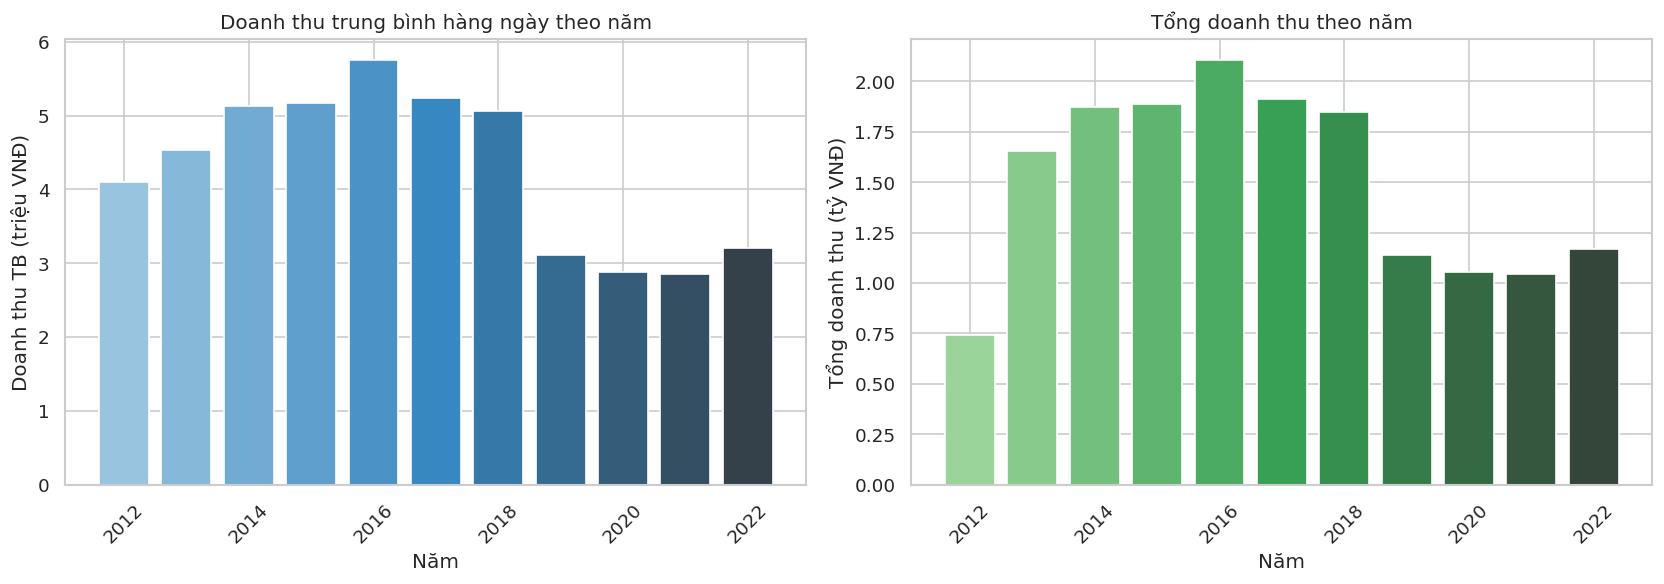

In [13]:
# ── 2.1 Xu hướng doanh thu hàng năm (Descriptive) ─────────────────────────
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month

yearly = sales.groupby('year')['Revenue'].agg(['mean', 'sum']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(yearly['year'], yearly['mean'] / 1e6, color=sns.color_palette('Blues_d', len(yearly)))
axes[0].set_title('Doanh thu trung bình hàng ngày theo năm')
axes[0].set_xlabel('Năm'); axes[0].set_ylabel('Doanh thu TB (triệu VNĐ)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(yearly['year'], yearly['sum'] / 1e9, color=sns.color_palette('Greens_d', len(yearly)))
axes[1].set_title('Tổng doanh thu theo năm')
axes[1].set_xlabel('Năm'); axes[1].set_ylabel('Tổng doanh thu (tỷ VNĐ)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig1_yearly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

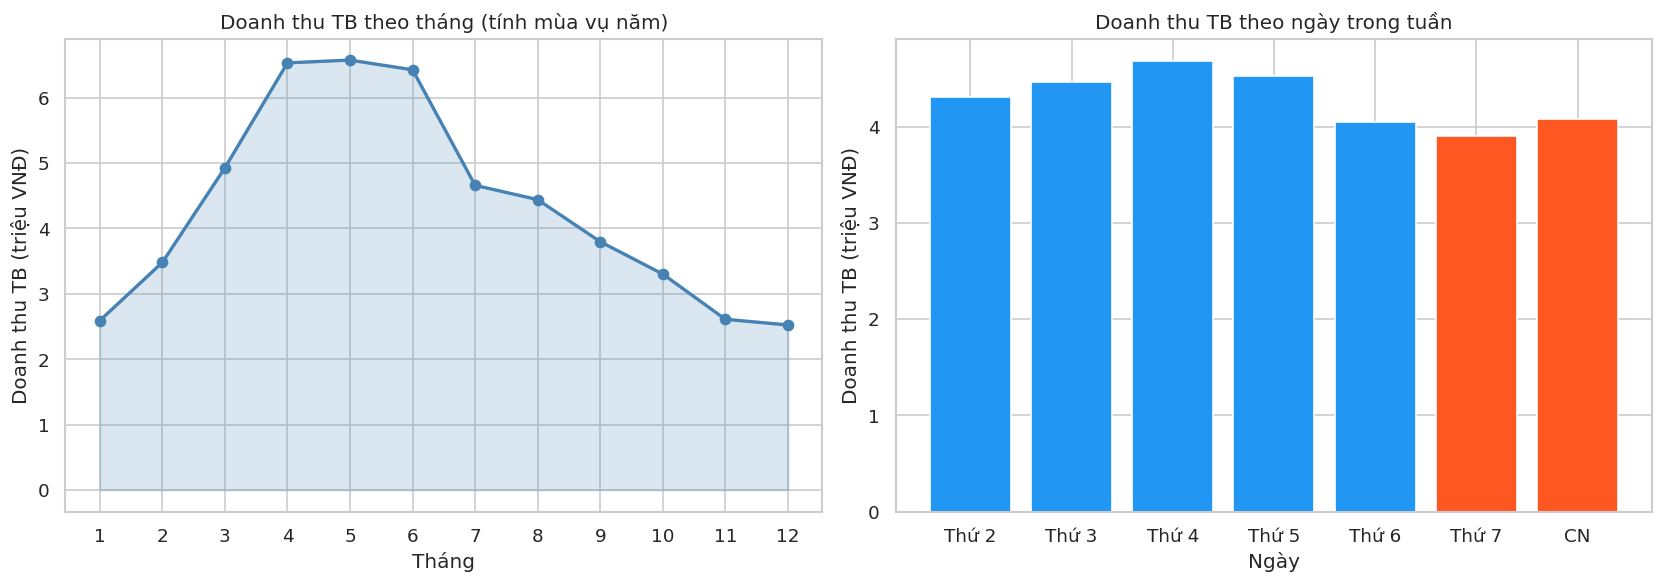

In [14]:
# ── 2.2 Tính mùa vụ (Seasonality) ────────────────────────────────────────
monthly_avg = sales.groupby('month')['Revenue'].mean()
dow_avg     = sales.groupby(sales['Date'].dt.dayofweek)['Revenue'].mean()
dow_labels  = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'CN']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(monthly_avg.index, monthly_avg.values / 1e6, 'o-', color='steelblue', lw=2)
axes[0].fill_between(monthly_avg.index, monthly_avg.values / 1e6, alpha=0.2, color='steelblue')
axes[0].set_title('Doanh thu TB theo tháng (tính mùa vụ năm)')
axes[0].set_xlabel('Tháng'); axes[0].set_ylabel('Doanh thu TB (triệu VNĐ)')
axes[0].set_xticks(range(1, 13))

axes[1].bar(range(7), dow_avg.values / 1e6, color=['#2196F3']*5 + ['#FF5722']*2)
axes[1].set_title('Doanh thu TB theo ngày trong tuần')
axes[1].set_xlabel('Ngày'); axes[1].set_ylabel('Doanh thu TB (triệu VNĐ)')
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(dow_labels)

plt.tight_layout()
plt.savefig('fig2_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

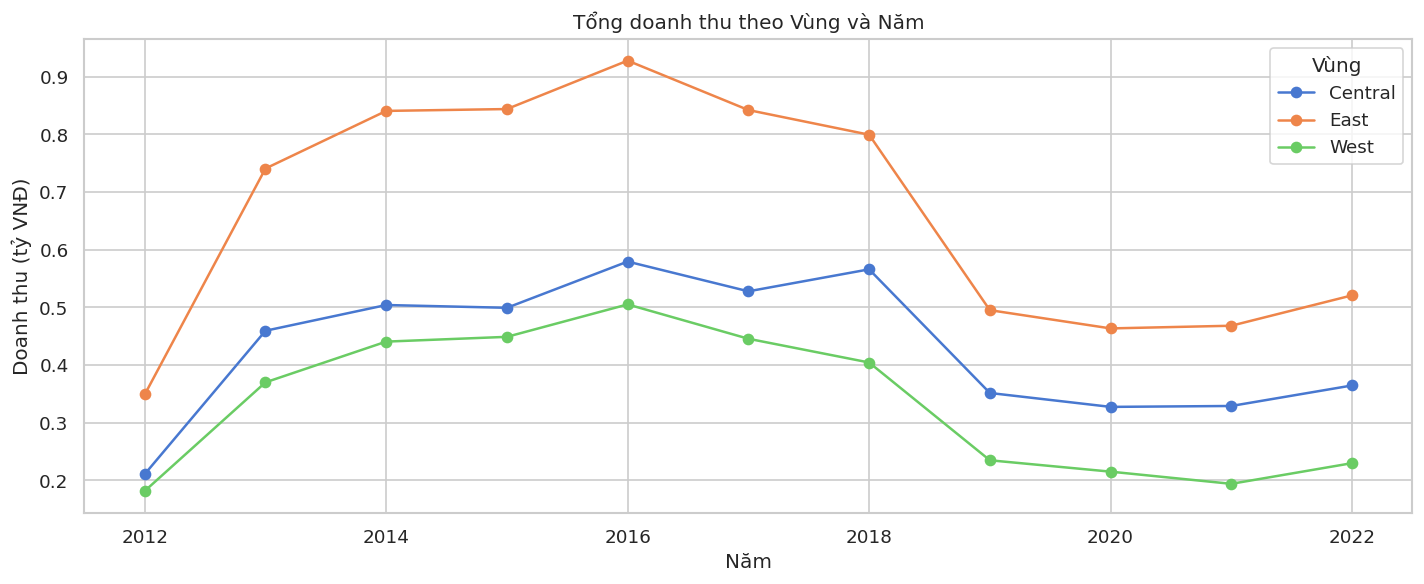

Tổng doanh thu theo vùng (triệu VNĐ):
region
East              7,291
Central           4,719
West              3,670


In [15]:
# ── 2.3 Phân tích theo vùng địa lý (Diagnostic) ──────────────────────────
orders_geo = orders.merge(geography[['zip', 'region', 'city']], on='zip', how='left')
pay_region = payments.merge(orders_geo[['order_id', 'region']], on='order_id')
pay_region['year'] = orders.set_index('order_id').loc[pay_region['order_id'], 'order_date'].dt.year.values

rev_region_yr = (pay_region.groupby(['year','region'])['payment_value']
                 .sum().unstack('region').fillna(0) / 1e9)

rev_region_yr.plot(figsize=(12, 5), marker='o')
plt.title('Tổng doanh thu theo Vùng và Năm')
plt.xlabel('Năm'); plt.ylabel('Doanh thu (tỷ VNĐ)')
plt.legend(title='Vùng')
plt.tight_layout()
plt.savefig('fig3_region_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

total_by_region = pay_region.groupby('region')['payment_value'].sum().sort_values(ascending=False)
print('Tổng doanh thu theo vùng (triệu VNĐ):')
print((total_by_region / 1e6).apply(lambda x: f'{x:>12,.0f}').to_string())

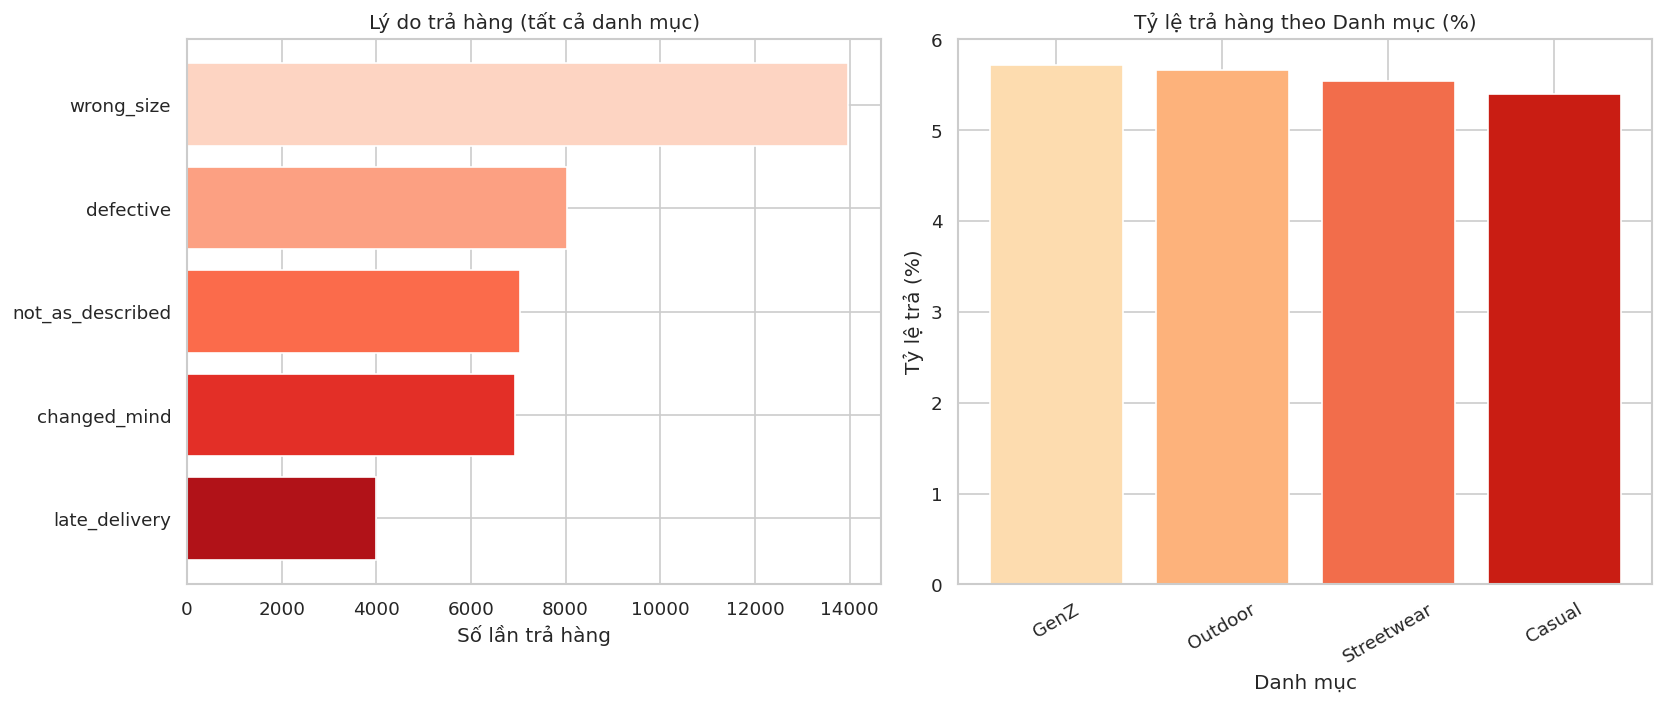

In [16]:
# ── 2.4 Phân tích trả hàng (Diagnostic) ──────────────────────────────────
returns_prod = returns.merge(products[['product_id', 'category', 'size', 'segment']], on='product_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lý do trả hàng
reason_counts = returns_prod['return_reason'].value_counts()
axes[0].barh(reason_counts.index[::-1], reason_counts.values[::-1],
             color=sns.color_palette('Reds_r', len(reason_counts)))
axes[0].set_title('Lý do trả hàng (tất cả danh mục)')
axes[0].set_xlabel('Số lần trả hàng')

# Return rate by category
oi_cat = order_items.merge(products[['product_id', 'category']], on='product_id')
ret_cat = returns_prod.groupby('category').size()
oi_cat_cnt = oi_cat.groupby('category').size()
ret_rate_cat = (ret_cat / oi_cat_cnt).sort_values(ascending=False)
axes[1].bar(ret_rate_cat.index, ret_rate_cat.values * 100,
            color=sns.color_palette('OrRd', len(ret_rate_cat)))
axes[1].set_title('Tỷ lệ trả hàng theo Danh mục (%)')
axes[1].set_xlabel('Danh mục'); axes[1].set_ylabel('Tỷ lệ trả (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig5_returns_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

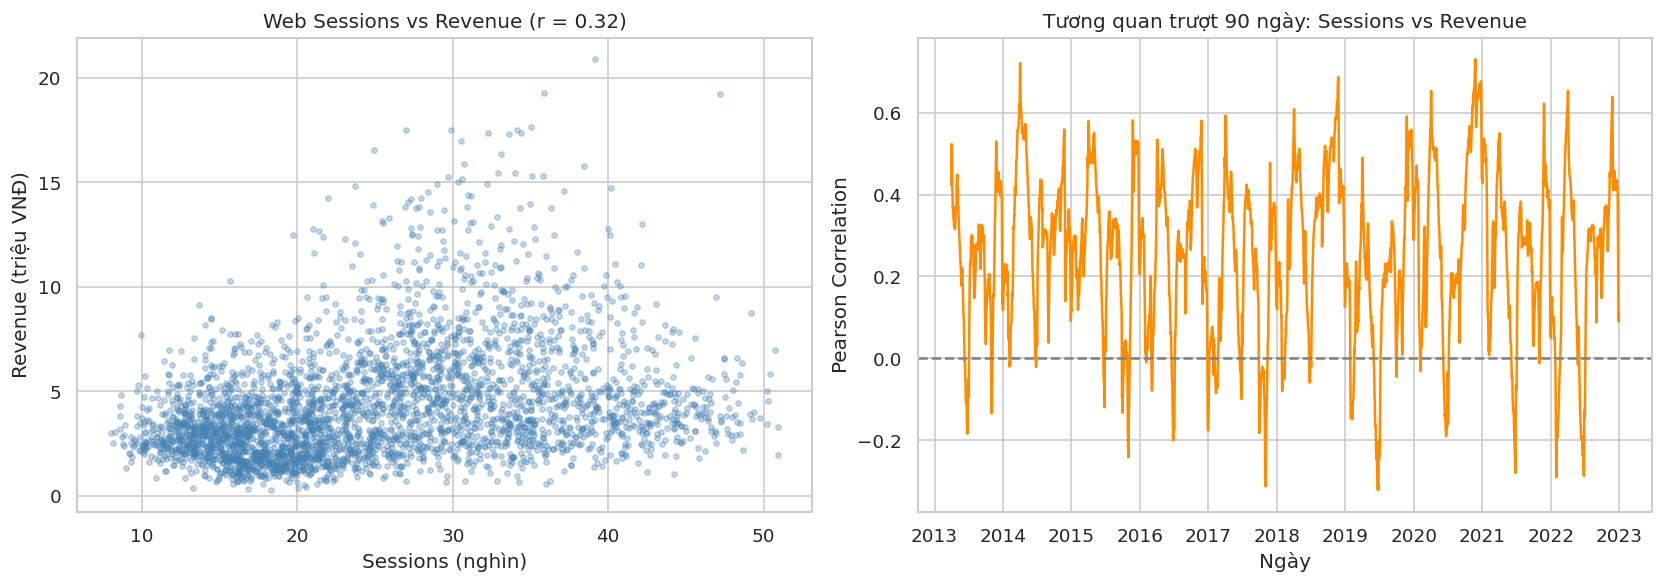

In [17]:
# ── 2.5 Web traffic vs Revenue (Predictive) ───────────────────────────────
# Aggregate daily traffic
wt_daily = web_traffic.groupby('date').agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum'),
    avg_bounce=('bounce_rate', 'mean')
).reset_index().rename(columns={'date': 'Date'})

merged = sales.merge(wt_daily, on='Date', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(merged['sessions'] / 1000, merged['Revenue'] / 1e6,
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Sessions (nghìn)'); axes[0].set_ylabel('Revenue (triệu VNĐ)')
axes[0].set_title(f"Web Sessions vs Revenue (r = {merged['sessions'].corr(merged['Revenue']):.2f})")

# Rolling correlation
merged_sorted = merged.sort_values('Date')
roll_corr = merged_sorted['sessions'].rolling(90).corr(merged_sorted['Revenue'])
axes[1].plot(merged_sorted['Date'], roll_corr, color='darkorange', lw=1.5)
axes[1].axhline(0, color='gray', ls='--')
axes[1].set_title('Tương quan trượt 90 ngày: Sessions vs Revenue')
axes[1].set_xlabel('Ngày'); axes[1].set_ylabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('fig6_traffic_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

corr = merged['sessions'].corr(merged['Revenue'])

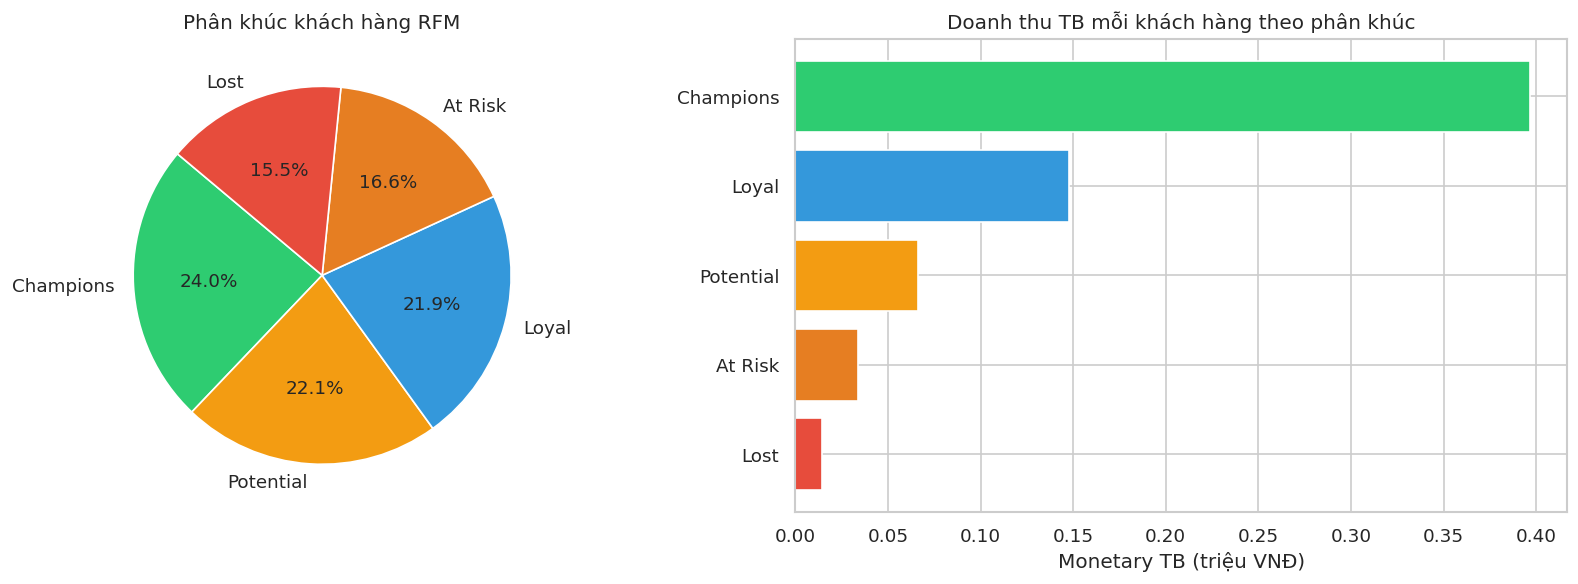

In [18]:
# ── 2.6 Cohort & RFM phân tích khách hàng (Prescriptive) ─────────────────
orders_cust = orders[orders['order_status'].isin(['delivered', 'shipped'])].copy()
payments_o  = payments[['order_id', 'payment_value']]
orders_pay  = orders_cust.merge(payments_o, on='order_id')

snapshot_date = orders_cust['order_date'].max()
rfm = orders_pay.groupby('customer_id').agg(
    recency   = ('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('payment_value', 'sum')
).reset_index()

# RFM scoring
rfm['R'] = pd.qcut(rfm['recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'],  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R'] + rfm['F'] + rfm['M']

def rfm_segment(score):
    if score >= 13: return 'Champions'
    elif score >= 10: return 'Loyal'
    elif score >= 7:  return 'Potential'
    elif score >= 5:  return 'At Risk'
    else: return 'Lost'

rfm['segment'] = rfm['RFM_score'].apply(rfm_segment)
seg_dist = rfm['segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_colors = {'Champions':'#2ecc71','Loyal':'#3498db','Potential':'#f39c12','At Risk':'#e67e22','Lost':'#e74c3c'}
axes[0].pie(seg_dist.values, labels=seg_dist.index, autopct='%1.1f%%',
            colors=[seg_colors[s] for s in seg_dist.index], startangle=140)
axes[0].set_title('Phân khúc khách hàng RFM')

seg_revenue = rfm.groupby('segment')['monetary'].mean().sort_values(ascending=True)
axes[1].barh(seg_revenue.index, seg_revenue.values / 1e6,
             color=[seg_colors[s] for s in seg_revenue.index])
axes[1].set_title('Doanh thu TB mỗi khách hàng theo phân khúc')
axes[1].set_xlabel('Monetary TB (triệu VNĐ)')

plt.tight_layout()
plt.savefig('fig7_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

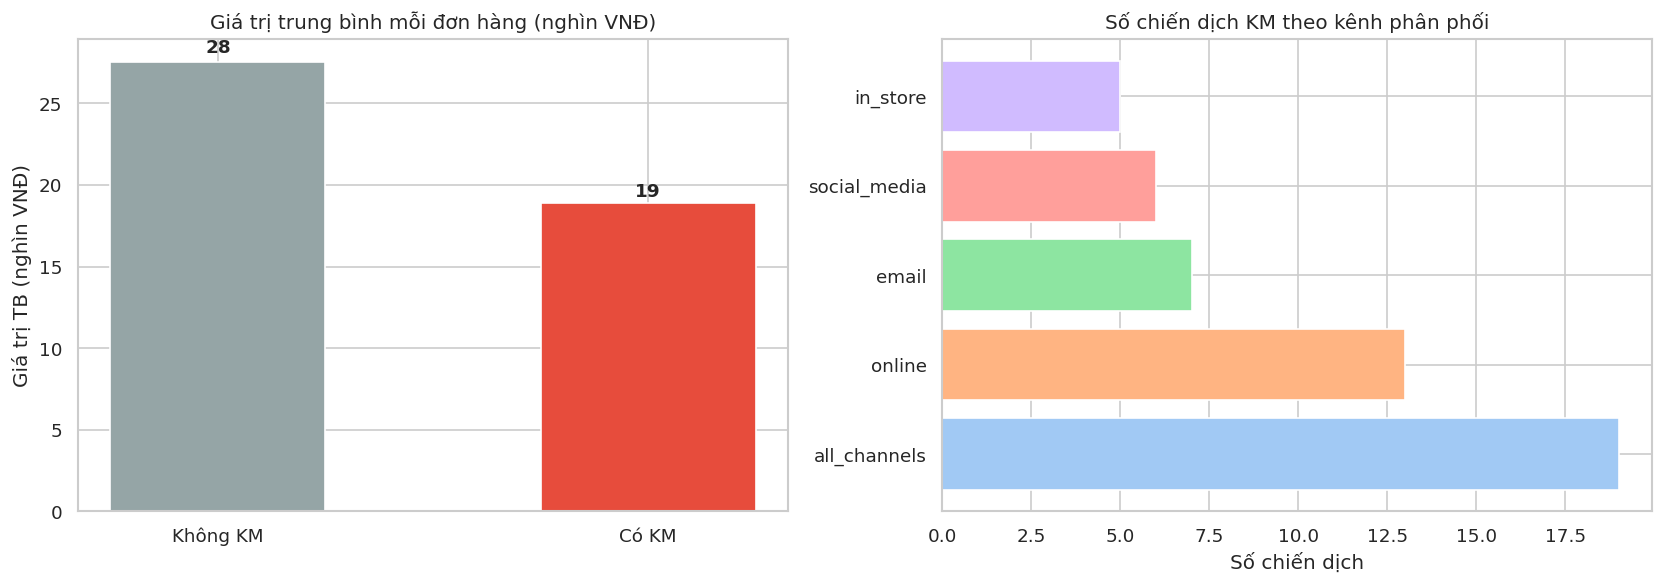

Thống kê discount value theo loại KM:
            count  mean       std   min   25%   50%   75%   max
promo_type                                                     
fixed         5.0  50.0  0.000000  50.0  50.0  50.0  50.0  50.0
percentage   45.0  15.0  3.931227  10.0  12.0  15.0  18.0  20.0


In [19]:
# ── 2.7 Phân tích khuyến mãi (Prescriptive) ───────────────────────────────
promo_items = order_items[order_items['promo_id'].notna()].copy()
promo_noitems = order_items[order_items['promo_id'].isna()].copy()

oi_order = order_items.copy()
oi_order['revenue_line'] = oi_order['quantity'] * oi_order['unit_price'] - oi_order['discount_amount']
order_val = oi_order.groupby('order_id').agg(
    total_rev=('revenue_line', 'sum'),
    has_promo=('promo_id', lambda x: x.notna().any())
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_p = ['Không KM', 'Có KM']
vals_p   = [order_val[~order_val['has_promo']]['total_rev'].mean(),
            order_val[order_val['has_promo']]['total_rev'].mean()]
axes[0].bar(labels_p, [v/1e3 for v in vals_p], color=['#95a5a6','#e74c3c'], width=0.5)
axes[0].set_title('Giá trị trung bình mỗi đơn hàng (nghìn VNĐ)')
axes[0].set_ylabel('Giá trị TB (nghìn VNĐ)')
for i, v in enumerate(vals_p):
    axes[0].text(i, v/1e3 * 1.02, f'{v/1e3:,.0f}', ha='center', fontweight='bold')

# Discount amount distribution
promo_stats = promotions.groupby('promo_type')['discount_value'].describe()

promo_channel = promotions['promo_channel'].value_counts(dropna=False).fillna('all_channels')
axes[1].barh(promo_channel.index.astype(str), promo_channel.values,
             color=sns.color_palette('pastel', len(promo_channel)))
axes[1].set_title('Số chiến dịch KM theo kênh phân phối')
axes[1].set_xlabel('Số chiến dịch')

plt.tight_layout()
plt.savefig('fig8_promotion.png', dpi=150, bbox_inches='tight')
plt.show()

print('Thống kê discount value theo loại KM:')
print(promo_stats)

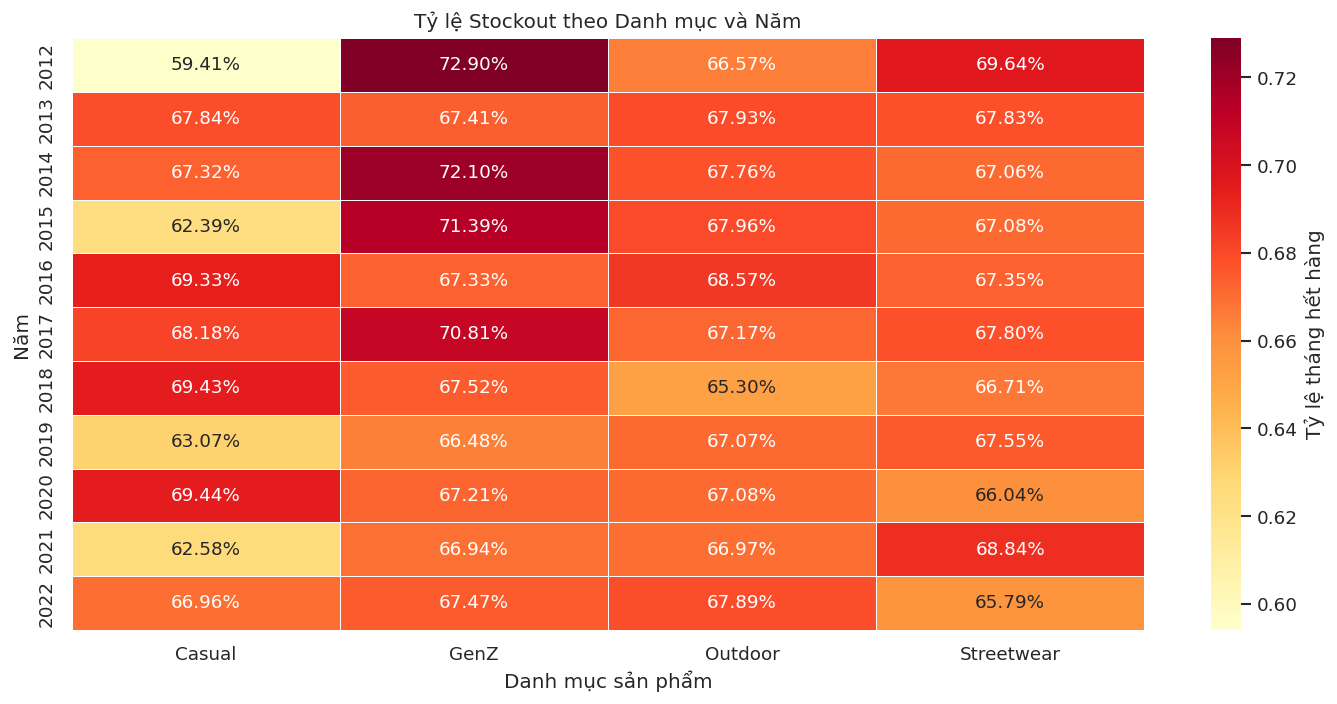

In [20]:
# ── 2.8 Inventory & Stockout Analysis (Prescriptive) ──────────────────────
inv_summary = inventory.groupby(['year', 'category']).agg(
    avg_stockout_days=('stockout_days', 'mean'),
    avg_fill_rate=('fill_rate', 'mean'),
    pct_stockout=('stockout_flag', 'mean')
).reset_index()

pivot_stockout = inv_summary.pivot(index='year', columns='category', values='pct_stockout')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_stockout, annot=True, fmt='.2%', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Tỷ lệ tháng hết hàng'})
plt.title('Tỷ lệ Stockout theo Danh mục và Năm')
plt.xlabel('Danh mục sản phẩm'); plt.ylabel('Năm')
plt.tight_layout()
plt.savefig('fig9_stockout.png', dpi=150, bbox_inches='tight')
plt.show()